# Modeling

In [3]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, classification_report, confusion_matrix
)

In [4]:
def prepare_xgboost_data(df):
    df = df.copy()  # Avoid modifying original data

    # Ensure DateTime is a datetime type
    if 'DateTime' in df.columns:
        df['Year'] = df['DateTime'].dt.year
        df['Month'] = df['DateTime'].dt.month
        df['Day'] = df['DateTime'].dt.day
        df['Hour'] = df['DateTime'].dt.hour
        df['Minute'] = df['DateTime'].dt.minute

        df.drop(columns=['DateTime'], inplace=True)  # Drop original DateTime column

    return df



Training on 0...


c:\Users\josea\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:59:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ 0 -> Precision: 0.8657, Recall: 0.9163, F1 Score: 0.8857


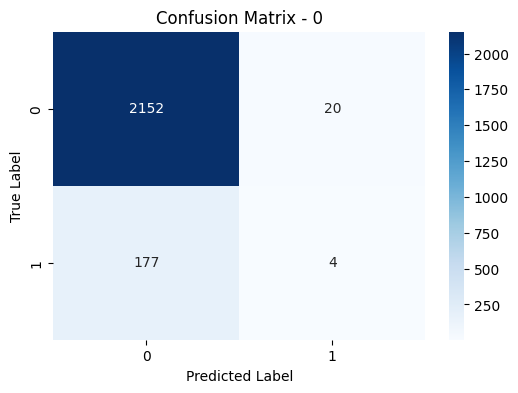


Training on 1...


c:\Users\josea\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:59:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ 1 -> Precision: 0.8599, Recall: 0.9197, F1 Score: 0.8852


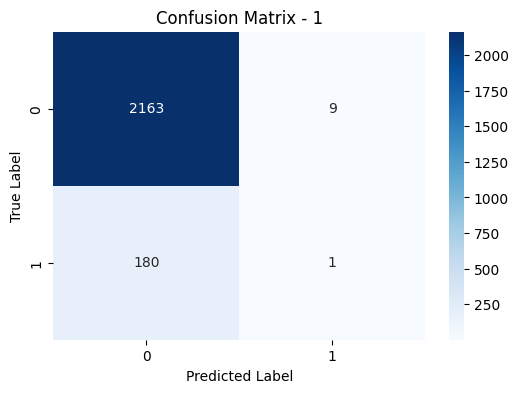


Training on 2...


c:\Users\josea\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:59:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ 2 -> Precision: 0.8698, Recall: 0.9201, F1 Score: 0.8918


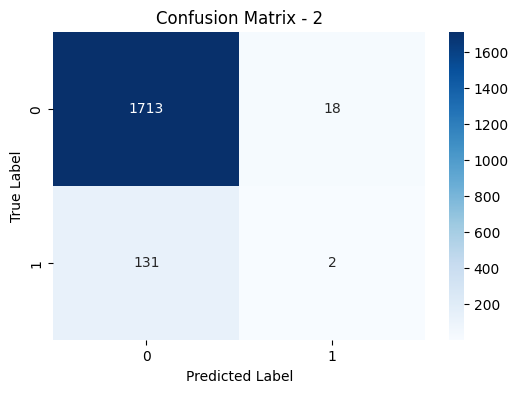


Training on 3...
✅ 3 -> Precision: 0.8621, Recall: 0.9249, F1 Score: 0.8924


c:\Users\josea\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:59:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


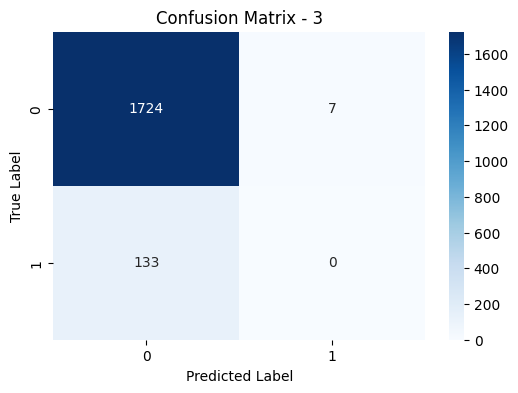


Training on 4...


c:\Users\josea\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:59:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ 4 -> Precision: 1.0000, Recall: 1.0000, F1 Score: 1.0000


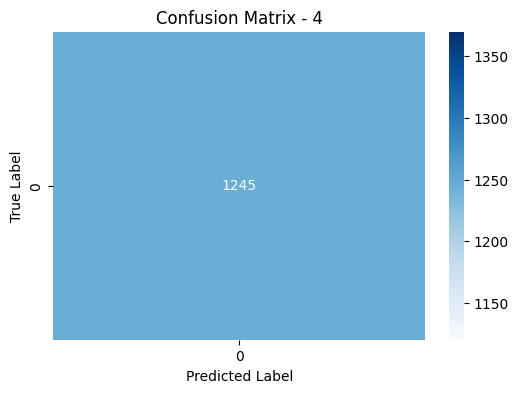


Training on 5...
✅ 5 -> Precision: 1.0000, Recall: 1.0000, F1 Score: 1.0000


c:\Users\josea\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:59:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


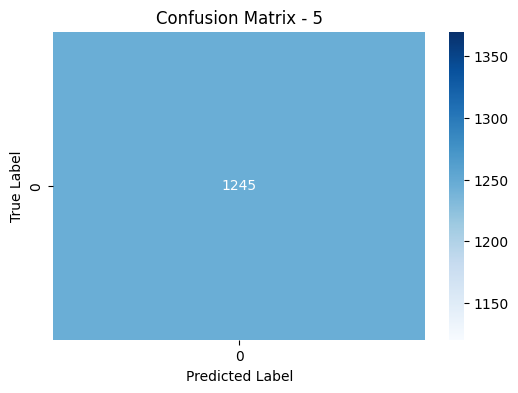


Training on 6...


c:\Users\josea\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:59:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ 6 -> Precision: 1.0000, Recall: 1.0000, F1 Score: 1.0000


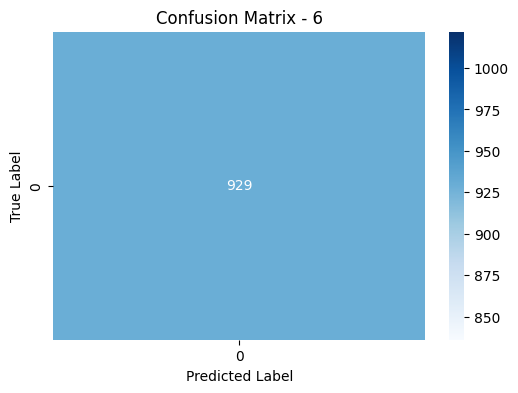


Training on 7...
✅ 7 -> Precision: 1.0000, Recall: 1.0000, F1 Score: 1.0000


c:\Users\josea\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:59:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


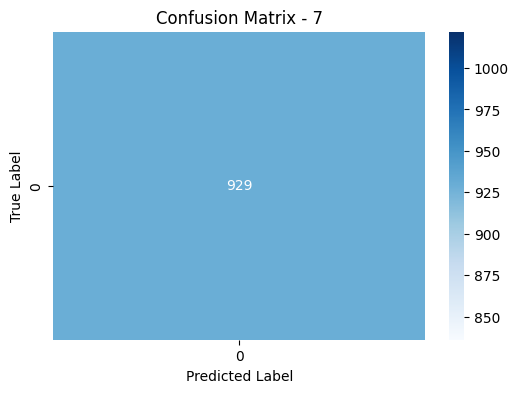


Training on 8...


c:\Users\josea\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:59:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ 8 -> Precision: 1.0000, Recall: 1.0000, F1 Score: 1.0000


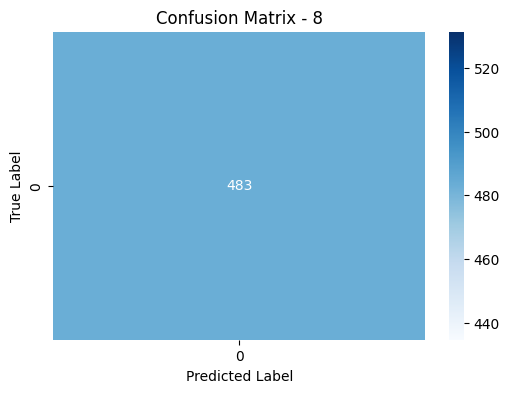


Training on 9...
✅ 9 -> Precision: 1.0000, Recall: 1.0000, F1 Score: 1.0000


c:\Users\josea\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:59:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


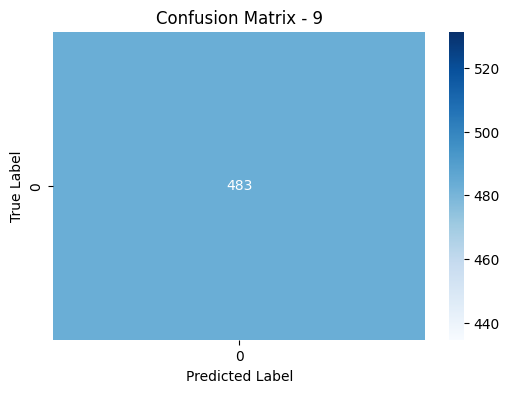


Training on 10...


c:\Users\josea\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:59:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoostError: [13:59:06] C:\actions-runner\_work\xgboost\xgboost\src\objective\./regression_loss.h:69: Check failed: base_score > 0.0f && base_score < 1.0f: base_score must be in (0,1) for logistic loss, got: 0

In [5]:
# Define paths
DATA_FOLDER = "DatasetCleaned"
RESULTS_FILE = "results.json"

# Load pipeline mapping
with open(os.path.join(DATA_FOLDER, "pipeline_metadata.json"), "r") as f:
    pipeline_mapping = json.load(f)

# Dictionary to store results
results = {}

# Iterate over all processed datasets
for pipeline_name in pipeline_mapping.keys():
    print(f"\nTraining on {pipeline_name}...")

    # Load train & test data
    train_path = os.path.join(DATA_FOLDER, f"pipeline_{pipeline_name}_train.pkl")
    test_path = os.path.join(DATA_FOLDER, f"pipeline_{pipeline_name}_test.pkl")
    
    train_df = pd.read_pickle(train_path)
    test_df = pd.read_pickle(test_path)

    # Prepare data for XGBoost
    train_df = prepare_xgboost_data(train_df)
    test_df = prepare_xgboost_data(test_df)

    # Extract features & target
    X_train, y_train = train_df.drop(columns=["event"]), train_df["event"]
    X_test, y_test = test_df.drop(columns=["event"]), test_df["event"]

    # Initialize XGBoost model
    model = XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)

    # Train model
    model.fit(X_train, y_train)

    # Predict on test set
    y_pred = model.predict(X_test)

    # Compute evaluation metrics
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")
    conf_matrix = confusion_matrix(y_test, y_pred)
    class_report = classification_report(y_test, y_pred, output_dict=True)

    # Store results
    results[pipeline_name] = {
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "confusion_matrix": conf_matrix.tolist(),
        "classification_report": class_report
    }

    print(f"✅ {pipeline_name} -> Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")

    # Plot confusion matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {pipeline_name}")
    plt.show()

# Save results to JSON
with open(RESULTS_FILE, "w") as f:
    json.dump(results, f, indent=4)

print("\n🔥 Training complete! Results saved in 'results.json'.")
